<a href="https://colab.research.google.com/github/arthireddy14/Deep_Learning/blob/main/fashion_mnist_cnn_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🛍 Scenario: Fashion Product Image Classifier
You are working as an AI Engineer for an e-commerce company.
The company wants to automatically classify clothing products from images into categories such as:
T-shirt
Trouser
Pullover
Dress
Coat
Sandal
Shirt
Sneaker
Bag
Ankle boot
The dataset contains 28×28 grayscale images of fashion items.
Your goal is to build a Convolutional Neural Network (CNN) that can classify these fashion products correctly.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from keras.layers import Dense,Flatten,Conv2D,MaxPooling2D
from keras import Sequential

Dataset Exploration
Load the Fashion-MNIST dataset and perform basic inspection.
Students must:
Load dataset using TensorFlow/Keras
Print:
Number of training images
Number of testing images
Display 10 random images with their labels
Goal:
Understand the dataset visually.

In [ ]:
(x_train,y_train),(x_test,y_test)=fashion_mnist.load_data()
print("Number of training images:", x_train.shape[0])
print("Number of testing images:", x_test.shape[0])

print("Image shape:", x_train.shape[1:])  # should be (28, 28)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Number of training images: 60000
Number of testing images: 10000
Image shape: (28, 28)


In [8]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [9]:
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

In [ ]:
class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

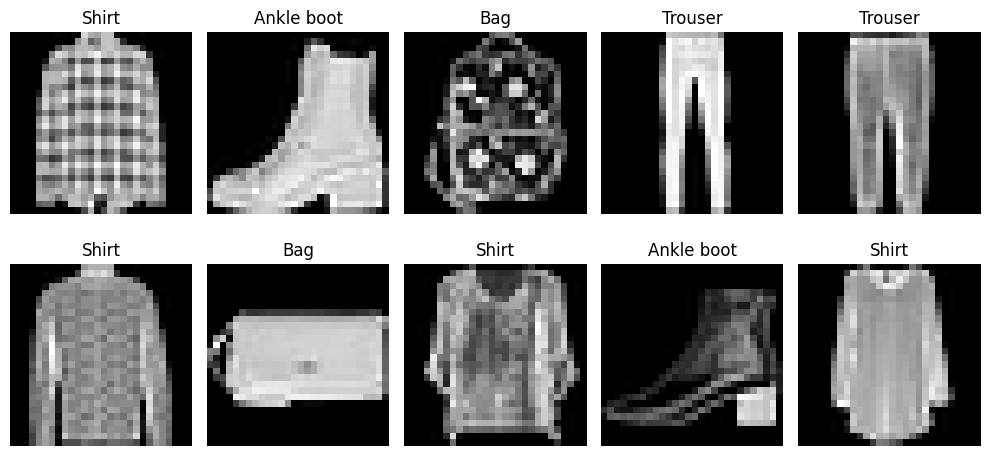

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,5))

for i in range(10):
    index = np.random.randint(0, len(x_train))

    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(class_names[y_train[index]])
    plt.axis('off')

plt.tight_layout()
plt.show()

The Fashion-MNIST dataset contains 60,000 training and 10,000 testing grayscale images of size 28×28. Each image represents a clothing item belonging to one of 10 categories. The dataset is balanced and suitable for image classification tasks. Visualization helped understand patterns and differences between categories

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN captures spatial features (edges, textures) from images, unlike ANN.

Conv2D-Extracts feature maps using filters

MaxPooling-Reduces dimensions and keeps important features

Softmax-Converts outputs into probabilities across 10 classes

In [11]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_data=(x_test, y_test)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8408 - loss: 0.4420 - val_accuracy: 0.8803 - val_loss: 0.3405
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8925 - loss: 0.2940 - val_accuracy: 0.8857 - val_loss: 0.3045
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9082 - loss: 0.2485 - val_accuracy: 0.9047 - val_loss: 0.2651
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9183 - loss: 0.2193 - val_accuracy: 0.9051 - val_loss: 0.2673
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9282 - loss: 0.1929 - val_accuracy: 0.8978 - val_loss: 0.2778
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9362 - loss: 0.1709 - val_accuracy: 0.9040 - val_loss: 0.2691
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9438 - loss: 0.1503 - val_accuracy: 0.9114 - val_loss: 0.2637
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9490 - loss: 0.1344 -

In [13]:
loss, accuracy = model.evaluate(x_test, y_test)
print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9131 - loss: 0.2894
Test Accuracy: 0.913100004196167


In [14]:
import numpy as np

predictions = model.predict(x_test)

# Example: first image
predicted_class = np.argmax(predictions[0])

print("Predicted:", class_names[predicted_class])
print("Actual:", class_names[y_test[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Predicted: Ankle boot
Actual: Ankle boot
